<a href="https://colab.research.google.com/github/Abhijith2005binu/AI-ML/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 2. UPLOAD DATASET
# ------------------------------------------------------------

uploaded = files.upload()

df = pd.read_csv("marvel_master_preprocessed.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Saving marvel_master_preprocessed.csv to marvel_master_preprocessed (1).csv
Dataset Shape: (161, 53)


,id,title,year,imdb_id,type,rated,runtime_min,genre,director,writer,...,tagline,decade_1940s,decade_1970s,decade_1980s,decade_1990s,decade_2000s,decade_2010s,decade_2020s,profit_usd,old_or_new
0,1,Captain America,1944,tt0036697,0,0,1.608821,"Action, Adventure, Sci-Fi","Elmer Clifton, John English","Royal K. Cole, Ronald Davidson, Basil Dickey",...,His greatest challenge...,True,False,False,False,False,False,False,0.251266,Old
1,2,The Amazing Spider-Man,1977,tt0076975,1,7,-1.585125,"Action, Adventure, Crime","Anthony Russo, Joe Russo","Chris McKenna, Erik Sommers, Stan Lee",...,The world's favorite adventure super hero in l...,False,True,False,False,False,False,False,0.251266,Old
2,3,Spider-Man,1977,tt0076975,1,7,-1.585125,"Action, Adventure, Crime","Anthony Russo, Joe Russo","Chris McKenna, Erik Sommers, Stan Lee",...,The world's favorite adventure super hero in l...,False,True,False,False,False,False,False,0.251266,Old
3,4,Dr. Strange,1978,tt0077469,0,7,-1.585125,"Action, Fantasy",Philip DeGuere Jr.,"Philip DeGuere Jr., Steve Ditko, Stan Lee",...,Battle of the sorcerers burns the screen with ...,False,True,False,False,False,False,False,0.251266,Old
4,5,The Incredible Hulk,1978,tt0076975,0,3,0.056208,"Action, Adventure, Sci-Fi","Anthony Russo, Joe Russo","Chris McKenna, Erik Sommers, Stan Lee",...,She loved the man... would the beast destroy t...,False,True,False,False,False,False,False,0.251266,Old


In [ ]:
print("\nMissing Values:")
display(
    df.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)



Missing Values:


,0
id,0
title,0
year,0
imdb_id,0
type,0
rated,0
runtime_min,0
genre,0
director,0
writer,0


In [ ]:
print("\nProfit Statistics:")
display(df["profit_usd"].describe())


# Calculate thresholds
low_threshold = df["profit_usd"].quantile(0.33)
high_threshold = df["profit_usd"].quantile(0.66)

print("Low Profit Threshold :", low_threshold)
print("High Profit Threshold:", high_threshold)


# Function to classify profit
def classify_profit(profit):

    if profit <= low_threshold:
        return "Low Profit"

    elif profit <= high_threshold:
        return "Medium Profit"

    else:
        return "High Profit"


# Create target column
df["profit_category"] = df["profit_usd"].apply(
    classify_profit
)


# Check distribution
print("\nProfit Category Distribution:")
print(df["profit_category"].value_counts())


Profit Statistics:


,profit_usd
count,1.610000e+02
mean,-2.454903e-16
std,5.813105e-01
min,-2.728722e+00
25%,-1.342524e-01
50%,-1.342524e-01
75%,2.512664e-01
max,2.114701e+00


Low Profit Threshold : -0.134252377984138
High Profit Threshold: 0.2306197387802632

Profit Category Distribution:
profit_category
Low Profit       87
High Profit      55
Medium Profit    19
Name: count, dtype: int64


In [ ]:
TARGET = "profit_category"

y = df[TARGET]


# ============================================================
# 6. REMOVE TARGET / LEAKAGE / UNSUITABLE FEATURES
# ============================================================

columns_to_drop = [

    # Original target
    "profit_usd",

    # Data leakage
    "revenue_usd",
    "budget_usd",

    # Identifiers
    "id",
    "imdb_id",

    # Text / high-cardinality columns
    "title",
    "plot",
    "tagline",
    "poster_url",
    "actors",
    "top5_cast",
    "writer",
    "director",
    "directors",
    "producers",
    "composer",
    "tmdb_keywords",

    # New target
    "profit_category"
]


# Keep only columns that exist
columns_to_drop = [
    col for col in columns_to_drop
    if col in df.columns
]


X = df.drop(
    columns=columns_to_drop
)


print("\nFeatures Used:")
print(X.columns.tolist())


Features Used:
['year', 'type', 'rated', 'runtime_min', 'genre', 'language', 'country', 'awards', 'imdb_rating', 'imdb_votes', 'rt_score', 'metacritic_score', 'box_office_usd', 'mcu_phase', 'universe', 'age_years', 'is_animated', 'is_tv_series', 'is_mcu_canon', 'tmdb_id', 'tmdb_genres', 'tmdb_rating', 'tmdb_votes', 'popularity', 'collection_name', 'production_countries', 'spoken_languages', 'status', 'decade_1940s', 'decade_1970s', 'decade_1980s', 'decade_1990s', 'decade_2000s', 'decade_2010s', 'decade_2020s', 'old_or_new']


In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['year', 'type', 'rated', 'runtime_min', 'imdb_rating', 'imdb_votes', 'box_office_usd', 'mcu_phase', 'universe', 'age_years', 'is_animated', 'is_tv_series', 'is_mcu_canon', 'tmdb_id', 'tmdb_rating', 'tmdb_votes', 'popularity', 'status']

Categorical Features:
['genre', 'language', 'country', 'awards', 'rt_score', 'metacritic_score', 'tmdb_genres', 'collection_name', 'production_countries', 'spoken_languages', 'decade_1940s', 'decade_1970s', 'decade_1980s', 'decade_1990s', 'decade_2000s', 'decade_2010s', 'decade_2020s', 'old_or_new']


In [ ]:
numeric_transformer = Pipeline(
    steps=[

        ("imputer",
         SimpleImputer(strategy="median")),

        ("scaler",
         StandardScaler())

    ]
)


# Categorical preprocessing
#
# Most frequent → handle missing values
# OneHotEncoder → convert categories to numbers

categorical_transformer = Pipeline(
    steps=[

        ("imputer",
         SimpleImputer(strategy="most_frequent")),

        ("onehot",
         OneHotEncoder(handle_unknown="ignore"))

    ]
)


# Combine both
preprocessor = ColumnTransformer(
    transformers=[

        ("num",
         numeric_transformer,
         numeric_features),

        ("cat",
         categorical_transformer,
         categorical_features)

    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])



Training Samples: 128
Testing Samples : 33


In [ ]:
svm_classifier = SVC(

    kernel="rbf",

    C=1.0,

    gamma="scale",

    random_state=42

)


# Complete pipeline
model = Pipeline(
    steps=[

        ("preprocessor",
         preprocessor),

        ("classifier",
         svm_classifier)

    ]
)

In [ ]:
print("\nTraining SVM Classifier...")

model.fit(
    X_train,
    y_train
)

print("Training Completed!")


# ============================================================
# 12. PREDICTION
# ============================================================

y_pred = model.predict(
    X_test
)


# ============================================================
# 13. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")
print("SVM CLASSIFICATION RESULTS")
print("======================================")

print(
    f"\nAccuracy: {accuracy:.4f}"
)

print(
    f"Accuracy Percentage: {accuracy * 100:.2f}%"
)



Training SVM Classifier...
Training Completed!

SVM CLASSIFICATION RESULTS

Accuracy: 0.7576
Accuracy Percentage: 75.76%


In [ ]:
print("\nClassification Report")
print("--------------------------------------")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

class_names = [

    "Low Profit",
    "Medium Profit",
    "High Profit"

]


cm = confusion_matrix(

    y_test,

    y_pred,

    labels=class_names

)


print("\nConfusion Matrix")
print("--------------------------------------")

print(cm)


Classification Report
--------------------------------------
               precision    recall  f1-score   support

  High Profit       0.82      0.82      0.82        11
   Low Profit       0.76      0.89      0.82        18
Medium Profit       0.00      0.00      0.00         4

     accuracy                           0.76        33
    macro avg       0.53      0.57      0.55        33
 weighted avg       0.69      0.76      0.72        33


Confusion Matrix
--------------------------------------
[[16  1  1]
 [ 3  0  1]
 [ 2  0  9]]


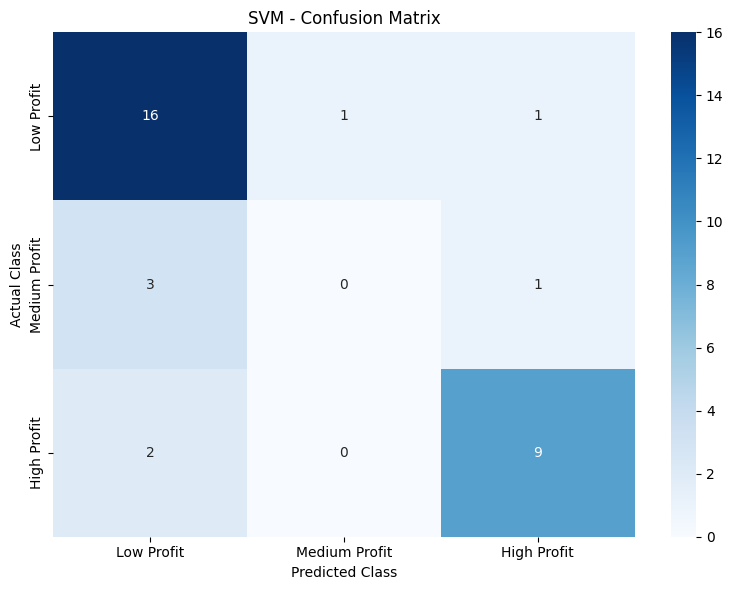

In [ ]:
plt.figure(
    figsize=(8, 6)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "SVM - Confusion Matrix"
)

plt.tight_layout()

plt.show()